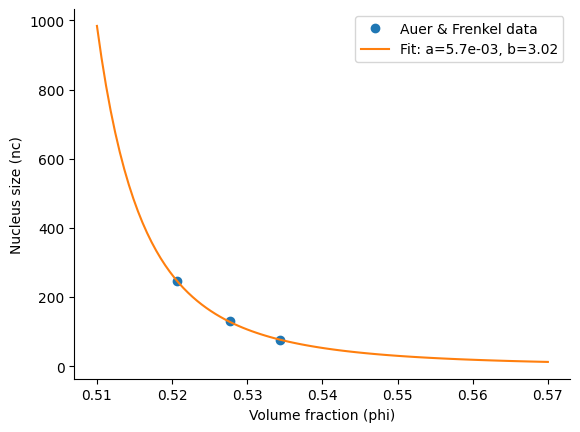

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


phix = 0.5431
phif0 = 0.535 #f stands for fluid.... maybe take 0.535 or 0.54
#  we need to decide how many events we want to see at this fraction

# assume that the rate at 0.535 is 1 event every 10 steps
J0 = 0.1

sigma = 1.0 # spatial unit is a particle size
Lz = 10000*sigma #vial size
Lx = Ly = Lz/2.
phi_freezing = 0.4917

auer_frenkel_nuclei= {"phi":[0.5207,0.5277,0.5343],"nc":[245,130,75]}

fit_nucleus = np.polyfit(auer_frenkel_nuclei["phi"], auer_frenkel_nuclei["nc"],  2)


def nucleus_model(phi,a,b):
    divergence = phi_freezing
    return a/(phi-divergence)**b

plt.plot( auer_frenkel_nuclei["phi"],auer_frenkel_nuclei["nc"], 'o', label='Auer & Frenkel data')
phis = np.linspace(0.51,0.57, 100)
popt, pcov = curve_fit(nucleus_model, auer_frenkel_nuclei["phi"], auer_frenkel_nuclei["nc"], p0=[1e-5,2.0])
plt.plot(phis, nucleus_model(phis, *popt), '-', label='Fit: a=%.1e, b=%.2f'%(popt[0],popt[1]))


# plt.plot(phis, np.polyval(fit_nucleus,phis), '-', label='Fit')
plt.ylabel('Nucleus size (nc)')
plt.xlabel('Volume fraction (phi)')
plt.legend()
plt.show()

def critical_nucleus_size(phi):
    return nucleus_model(phi, *popt)



Text(0, 0.5, 'Nucleation rate J')

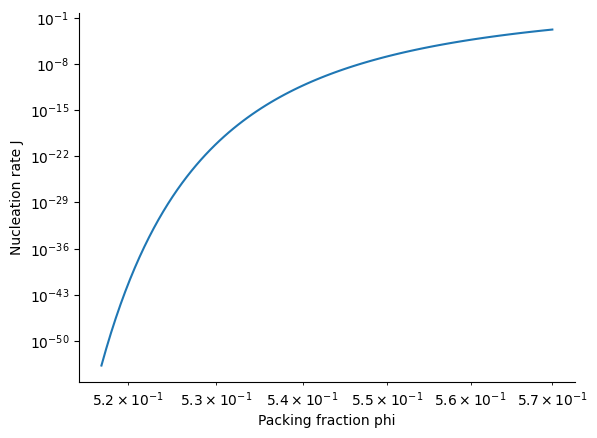

In [ ]:
import vedo
from vedo import Sphere, Box, show, Plotter

def render_frame(crystallites, interface_height, Lx, Ly, Lz, frame_number, phif):
    # particle positions and radii
    centers = np.array([c.position for c in crystallites])
    radii   = np.array([c.size/2 for c in crystallites])  # assuming size=diameter

    # create spheres as glyphs
    spheres = [Sphere(pos=c, r=r, res=12, alpha=0.5,c='lightblue') for c,r in zip(centers, radii)]

    # create a box representing the interface as a block
    interface_block = Box(pos=(Lx/2, Ly/2, interface_height/2),
                          length=Lx, width=Ly, height=interface_height,
                          c='lightblue', alpha=0.5)
    # Create fluid block with color mapping from packing fraction
    # Linear interpolation between red (low phi) and green (high phi)
    green_component = max(0.0, (phif - phi_freezing) / (phif0 - phi_freezing))
    red_component   = min(1.0, (phif0 - phif) / (phif0 - phi_freezing))
    fluid_block = Box(pos=(Lx/2, Ly/2, interface_height+(Lz-interface_height)/2),
                      length=Lx, width=Ly, height=Lz-interface_height,
                      c=(red_component, green_component, 0), alpha=0.1)
    # wireframe bounding box
# wireframe box
    wire_box = Box(pos=(Lx/2, Ly/2, Lz/2), length=Lx, width=Ly, height=Lz)
    wire_box = wire_box.wireframe().c('black').lw(1.5)  # convert to wireframe, color, linewidth

    # setup offscreen plotter
    plotter = Plotter(offscreen=True, size=(600,1200))


    plotter.show(spheres + [interface_block, wire_box,fluid_block], resetcam=False,        
                     
         )
        # configure camera manually for orthographic lateral view
    cam = plotter.camera
    cam.SetPosition(Lx*1.5, Ly/2, Lz/2)         # camera position
    cam.SetFocalPoint(Lx/2, Ly/2, Lz/2)         # look at center
    cam.SetViewUp(0,0,1)                         # z up
    cam.SetParallelProjection(True)              # orthographic
    cam.SetParallelScale(Lz)                     # scale of view

    # save screenshot
    plotter.screenshot(f'frame_{frame_number:05d}.png')
    plotter.close()


class Crystallite:
    def __init__(self, position, size, phix):
        self.position = position
        self.size = size
        self.V = np.pi / 6 * size ** 3
        self.N = self.V * phix

    def grow(self, growth_rate, dt, phix, phi_fluid):
        self.size += growth_rate(phi_fluid) * dt
        self.V = np.pi / 6 * self.size ** 3
        self.N = self.V * phix
    
dz = sigma
phif = np.ones(int(Lz//dz))*phif0
nz = len(phif)
N = Lx*Ly*Lz*phif0

V = Lx*Ly*Lz

tmax = 200
dt = 0.1
niter = int(tmax/dt)
crystallites = []
interface = 0.0

phi_f_t = []
ts = []
interface_t = []

def growth_rate( phi, divergence=0.64, g0=100):
    return  g0*(1 - phi/divergence)**2
            
def nucleation_rate_J(phi):
    """Simple empirical model for nucleation rate as a function of packing fraction"""
    # # return 1
    # J0 = 10
    # A =1e-4
    # divergence = 0.492
    # check data-graph fit:
    return 10**(1.48584 + (-0.0135262)/(phi - 0.4917)**2.2612)

    
global_sedimentation_rate = .01 # sedimentation rate in sigma per unit time, to be linked to size and packing fraction
# take peclet Peclet number to be 1 or 10
Pe = 1


_phis_ = np.linspace(0.517,0.57,100)
_Js_ = [nucleation_rate_J(phi) for phi in _phis_]
plt.loglog(_phis_, _Js_)
plt.xlabel('Packing fraction phi')
plt.ylabel('Nucleation rate J')

In [14]:

fxyz = open('ftraj.xyz', 'w')
time = 0
frame_interval = 0.03
next_frame_time = 0.0

for iteration in range(niter):
    time += dt
    if np.random.rand() < nucleation_rate_J(phif.mean())*dt:
        # pick a random position in the vial
        x = np.random.uniform(0,Lx)
        y = np.random.uniform(0,Ly)
        z = np.random.uniform(interface,Lz)
        centre = min(int(z/dz),nz-1)
        if z> Lz:
            print("z out of bounds!")
            print("picked z=%.2f, centre=%d"%(z,centre))

        lc = critical_nucleus_size(phif[centre])
        print("time %.2f: nucleated crystallite at z=%.2f with size lc=%.2f at packing %.3f"%(time, z, lc, phif[centre]))
        crystallite = Crystallite(position=[x, y, z], size=lc, phix=phix)
        crystallites.append(crystallite)


    # move crystallites down due to sedimentation (simple model)
    copy = []
    for c in crystallites:
        phi = phif[int(c.position[2]//dz)]
        # growth
        c.grow(growth_rate, dt, phix,phi)
        sedimentation_rate = global_sedimentation_rate*c.size**2*(1-phi**3)/(1+2*phi+1.492*phi*(1-phi**3))
        c.position[2] -= sedimentation_rate * dt
        if  sedimentation_rate * dt>100:
            # , f"Speed too fast {sedimentation_rate*dt}"
            # refine timestep to capture sedimentation properly
            dt = dt/10
        if c.position[2] < interface:
            # increment the interface
            interface += c.V/(Lx*Ly)
            # pass
        else:
            copy.append(c)

    # Keep checking if interface rise causes more crystallites to be absorbed
    changed = True
    while changed:
        changed = False
        final_copy = []
        for c in copy:
            if c.position[2] < interface:
                # This crystallite is now below the updated interface, absorb it
                interface += c.V/(Lx*Ly)
                changed = True
            else:
                final_copy.append(c)
        copy = final_copy

    crystallites = copy

        # recompute phif by removing the particles in the crystallites
    Vcrystallites = sum(c.V for c in crystallites)
    Ncrystallites = sum(c.N for c in crystallites)
    Nf = N - Ncrystallites - interface*Lx*Ly*phix
   
    # update fluid volume fraction
    phif_new = Nf/(V - Vcrystallites-interface*Lx*Ly)
    phif = np.ones(nz)*phif_new

    phi_f_t.append(phif.mean())
    ts.append(time)
    interface_t.append(interface)






    # write xyz file
    fxyz.write(f"{len(crystallites)}\n")
    fxyz.write(f"Time {time:.2f}\n")
    for c in crystallites:
        fxyz.write(f"A {c.position[0]:.4f} {c.position[1]:.4f} {c.position[2]:.4f} {c.size:.4f}\n")  

    if time >= next_frame_time:
        render_frame(crystallites, interface, Lx, Ly, Lz, iteration,phif_new)
        next_frame_time += frame_interval

    if phif_new<phi_freezing:
        print("Reached freezing point, stopping simulation")
        print("Number of crystallites:", len(crystallites))

        # break

# final state
render_frame(crystallites, interface, Lx, Ly, Lz, iteration,phif_new)

fxyz.close()



Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false


KeyboardInterrupt: 

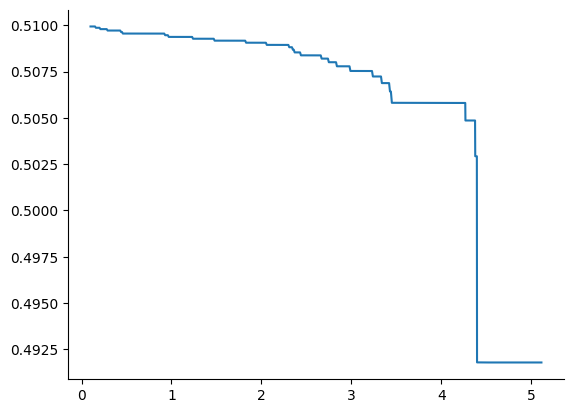

In [4]:
plt.plot(ts, phi_f_t)

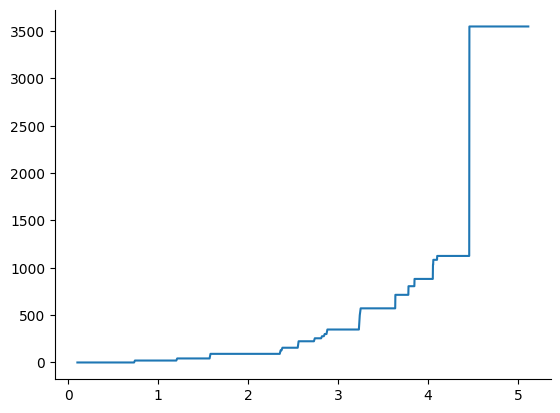

In [5]:
plt.plot(ts, interface_t)

## TODO 

- estimate the error in the volume fraction from lever rule:
    - get the interface

In [6]:
ts

[0.1,
 0.11,
 0.12,
 0.13,
 0.14,
 0.15000000000000002,
 0.16000000000000003,
 0.17000000000000004,
 0.18000000000000005,
 0.19000000000000006,
 0.20000000000000007,
 0.21000000000000008,
 0.22000000000000008,
 0.2300000000000001,
 0.2400000000000001,
 0.2500000000000001,
 0.2600000000000001,
 0.27000000000000013,
 0.28000000000000014,
 0.29000000000000015,
 0.30000000000000016,
 0.31000000000000016,
 0.3200000000000002,
 0.3300000000000002,
 0.3400000000000002,
 0.3500000000000002,
 0.3600000000000002,
 0.3700000000000002,
 0.3800000000000002,
 0.39000000000000024,
 0.40000000000000024,
 0.41000000000000025,
 0.42000000000000026,
 0.43000000000000027,
 0.4400000000000003,
 0.4500000000000003,
 0.4600000000000003,
 0.4700000000000003,
 0.4800000000000003,
 0.4900000000000003,
 0.5000000000000003,
 0.5100000000000003,
 0.5200000000000004,
 0.5300000000000004,
 0.5400000000000004,
 0.5500000000000004,
 0.5600000000000004,
 0.5700000000000004,
 0.5800000000000004,
 0.5900000000000004,
 0.